# Deep Learning project - Group 8

This work was conducted by:

Alexandre Batista - 20250419 <br>
Daniel Caridade - 20211588 <br>
Luis Mendes - 20221945 <br>
Mehmet Karaca - 20250344 <br>
Veronica mendes - 20221945

# 0. Library installation & importation

__`Step 1`__ - Installing the required libraries. <br>

Note: Uncomment the cell below if the libraries are not already installed in your environment, otherwise leave it commented as it is.

In [11]:
# Library for creating a tree map
!pip install squarify

# Library for performing perceptual hashing
!pip install imagehash

__`Step 2`__ Loading the required libraries for the notebook.

In [3]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import squarify
import hashlib
import imagehash
import numpy as np

from collections import defaultdict
from PIL import Image
from itertools import combinations

# 1. Data Integration

__`Step 3`__ - Mounting the notebook to Google Drive.

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


__`Step 4`__ - Importing the dataset into Google Collab.

In [5]:
# Creating a variable that stores the path to the dataset
data_path = '/content/drive/MyDrive/Deep Learning 2526/Project/wikiart'

# Create the dataset from the directory
data = tf.keras.utils.image_dataset_from_directory(
    data_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42
)

# Print dataset the number and name of the classes
class_names = data.class_names
print(f"Classes: {class_names}")

Found 13356 files belonging to 23 classes.
Classes: ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


Note for future me: All the images are 512x512, if the model is underperforming with 224x224 try using 512x512 instead. The drawbacks is that this will take more time to run, and maybe it will require me to do some adjustments especially when working with pre-trained models.

# 2. Data Understanding

__`Step 5`__ - Checking for class imbalance in the dataset.

Total samples: 13356

Class distribution:
----------------------------------------
Vincent_van_Gogh: 1322 samples (9.90%)
Nicholas_Roerich: 1274 samples (9.54%)
Pierre_Auguste_Renoir: 975 samples (7.30%)
Claude_Monet: 934 samples (6.99%)
Pyotr_Konchalovsky: 650 samples (4.87%)
Camille_Pissarro: 621 samples (4.65%)
Albrecht_Durer: 580 samples (4.34%)
John_Singer_Sargent: 549 samples (4.11%)
Rembrandt: 544 samples (4.07%)
Marc_Chagall: 536 samples (4.01%)
Pablo_Picasso: 534 samples (4.00%)
Gustave_Dore: 528 samples (3.95%)
Boris_Kustodiev: 444 samples (3.32%)
Edgar_Degas: 428 samples (3.20%)
Paul_Cezanne: 416 samples (3.11%)
Ivan_Aivazovsky: 404 samples (3.02%)
Martiros_Saryan: 403 samples (3.02%)
Eugene_Boudin: 389 samples (2.91%)
Childe_Hassam: 385 samples (2.88%)
Ilya_Repin: 378 samples (2.83%)
Ivan_Shishkin: 364 samples (2.73%)
Raphael_Kirchner: 362 samples (2.71%)
Salvador_Dali: 336 samples (2.52%)


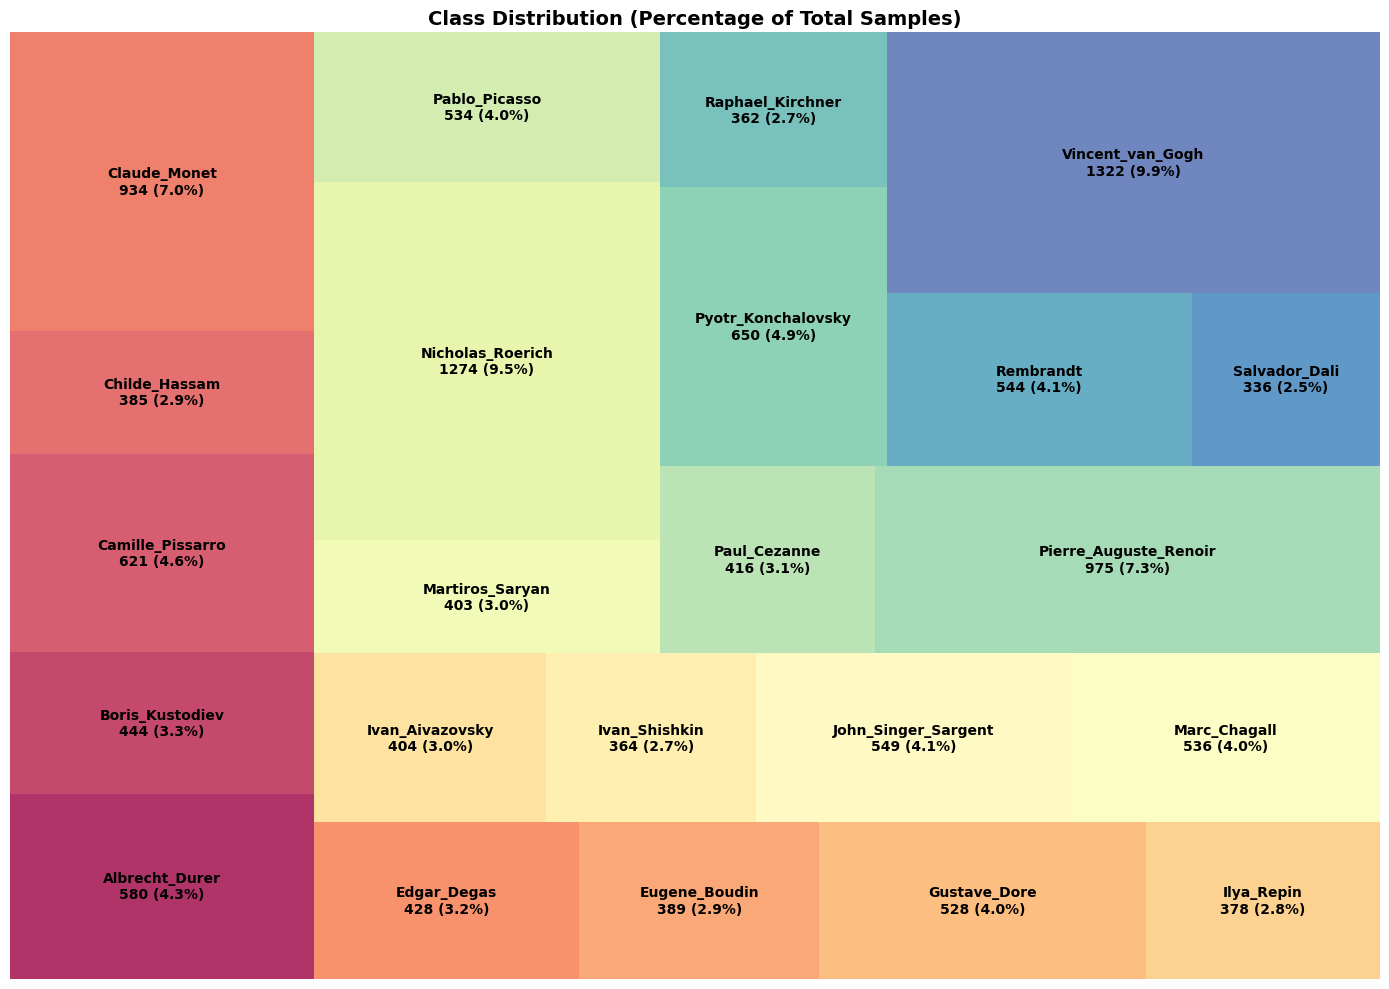

In [15]:
# Counting the number of images per class
class_counts = {}
for class_name in class_names:
    class_folder = os.path.join(data_path, class_name)
    class_counts[class_name] = len(os.listdir(class_folder))

total_samples = sum(class_counts.values())

# Printing the class distribution
print(f"Total samples: {total_samples}\n")
print("Class distribution:")
print("-" * 40)
for class_name, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / total_samples) * 100
    print(f"{class_name}: {count} samples ({percentage:.2f}%)")

# Treemap visualization
# Preparing the data for creating the treemap
labels = [f"{name}\n{count} ({count/total_samples*100:.1f}%)"
          for name, count in class_counts.items()]
sizes = list(class_counts.values())
colors = plt.cm.Spectral([i / len(class_counts) for i in range(len(class_counts))])

# Create the treemap
plt.figure(figsize=(14, 10))
squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.8,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold'})
plt.title('Class Distribution (Percentage of Total Samples)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

While there exists some class imbalanced, it is not very severe. The most represented class has fairly 10% of the total observations, while the least represented has 2.52% of the total observations.

This maybe a natural case of data imbalance, as different artists may have more works (paitings, drawings, portraits) than others, nonetheless oversampling or undersampling techniques might be beneficial if the performance in the least represented classes is significantly lower.

__`Step 6`__ - Checking for duplicates paths in the data.

In [16]:
def get_image_hash(image_path):
    """Generate MD5 hash of image file."""
    with open(image_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# Find all image hashes
hash_to_paths = defaultdict(list)

for class_name in class_names:
    class_folder = os.path.join(data_path, class_name)
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        try:
            img_hash = get_image_hash(img_path)
            hash_to_paths[img_hash].append(img_path)
        except Exception as e:
            print(f"Error reading {img_path}: {e}")

# Find duplicates
duplicates = {h: paths for h, paths in hash_to_paths.items() if len(paths) > 1}

# Report results
total_images = sum(len(paths) for paths in hash_to_paths.values())
duplicate_count = sum(len(paths) - 1 for paths in duplicates.values())

print(f"Total images scanned: {total_images}")
print(f"Unique images: {total_images - duplicate_count}")
print(f"Duplicate images: {duplicate_count}")
print(f"Duplicate groups: {len(duplicates)}")

if duplicates:
    print("\nDuplicate groups found:")
    print("-" * 50)
    for i, (h, paths) in enumerate(duplicates.items(), 1):
        print(f"\nGroup {i} ({len(paths)} copies):")
        for p in paths:
            # Show relative path for readability
            rel_path = p.replace(data_path + '/', '')
            print(f"  {rel_path}")
else:
    print("\nNo duplicates found!")

Total images scanned: 13356
Unique images: 13338
Duplicate images: 18
Duplicate groups: 18

Duplicate groups found:
--------------------------------------------------

Group 1 (2 copies):
  Childe_Hassam/childe-hassam_the-norwegian-cottage.jpg
  Childe_Hassam/childe-hassam_the-norwegian-cottage-1.jpg

Group 2 (2 copies):
  Childe_Hassam/childe-hassam_view-of-florence-from-san-miniato.jpg
  Childe_Hassam/childe-hassam_view-of-florence-from-san-miniato-1.jpg

Group 3 (2 copies):
  Paul_Cezanne/paul-cezanne_apples-1878 (1).jpg
  Paul_Cezanne/paul-cezanne_apples-1878.jpg

Group 4 (2 copies):
  Paul_Cezanne/paul-cezanne_a-turn-in-the-road-1882 (1).jpg
  Paul_Cezanne/paul-cezanne_a-turn-in-the-road-1882.jpg

Group 5 (2 copies):
  Paul_Cezanne/paul-cezanne_a-painter-at-work-1875 (1).jpg
  Paul_Cezanne/paul-cezanne_a-painter-at-work-1875.jpg

Group 6 (2 copies):
  Paul_Cezanne/paul-cezanne_achille-emperaire (1).jpg
  Paul_Cezanne/paul-cezanne_achille-emperaire.jpg

Group 7 (2 copies):
  Paul_C

__`Step 6.1`__ - Checking for very similar images in the dataset, trying to find masked duplicates.

In [17]:
def get_perceptual_hash(image_path):
    """Generate perceptual hash of image."""
    try:
        img = Image.open(image_path)
        return imagehash.phash(img)
    except Exception as e:
        return None

# Find similar images within each class
similar_pairs_per_class = {}
images_to_remove = []  # Store one image from each duplicate pair
hash_threshold = 5  # Images with hash difference <= 5 are considered similar

for class_name in class_names:
    print(f"Processing {class_name}...")
    class_folder = os.path.join(data_path, class_name)

    # Get all image paths and their hashes
    image_hashes = []
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        img_hash = get_perceptual_hash(img_path)
        if img_hash is not None:
            image_hashes.append((img_path, img_hash))

    # Compare all pairs within the class
    similar_pairs = []
    for i in range(len(image_hashes)):
        for j in range(i + 1, len(image_hashes)):
            path1, hash1 = image_hashes[i]
            path2, hash2 = image_hashes[j]
            diff = hash1 - hash2
            if diff <= hash_threshold and diff > 0:  # Similar but not identical
                similar_pairs.append((path1, path2, diff))
                images_to_remove.append(path2)  # Keep first, mark second for removal

    if similar_pairs:
        similar_pairs_per_class[class_name] = similar_pairs

# Creating a variable that stores the path of the images to remove
images_to_remove = list(set(images_to_remove))

# Report results
print("\n" + "=" * 60)
print("RESULTS")
print("=" * 60)

total_pairs = sum(len(pairs) for pairs in similar_pairs_per_class.values())
print(f"\nTotal similar pairs found: {total_pairs}")
print(f"Unique images to remove: {len(images_to_remove)}")

for class_name in class_names:
    if class_name in similar_pairs_per_class:
        pairs = similar_pairs_per_class[class_name]
        print(f"\n{class_name}: {len(pairs)} similar pairs found")
    else:
        print(f"\n{class_name}: No similar images found")

# Visualize one example per class
classes_with_similar = [c for c in class_names if c in similar_pairs_per_class]

if classes_with_similar:
    n_classes = len(classes_with_similar)

    fig, axes = plt.subplots(n_classes, 2, figsize=(10, 5 * n_classes))

    if n_classes == 1:
        axes = [axes]

    for idx, class_name in enumerate(classes_with_similar):
        path1, path2, diff = similar_pairs_per_class[class_name][0]

        img1 = Image.open(path1)
        img2 = Image.open(path2)

        axes[idx][0].imshow(img1)
        axes[idx][0].set_title(f"{class_name}\n{os.path.basename(path1)}", fontsize=9)
        axes[idx][0].axis("off")

        axes[idx][1].imshow(img2)
        axes[idx][1].set_title(f"Hash diff: {diff}\n{os.path.basename(path2)}", fontsize=9)
        axes[idx][1].axis("off")

    fig.suptitle(
        "Similar Image Pairs (One Example Per Class)",
        fontsize=12,
        fontweight="bold",
        y=0.98
    )

    fig.subplots_adjust(hspace=0.4, wspace=0.3)
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    plt.show()

else:
    print("\nNo similar images found in any class!")

Output hidden; open in https://colab.research.google.com to view.

While there aren't much, some very similar images where found. They are mainly the same painting with just a different shading of images. <br>

In total there are 52 duplicate pairs that need to be addressed.

__`Step 7`__ - Checking how heterogeneous each class images are.

In [ ]:
def get_perceptual_hash(image_path):
    """Generate perceptual hash of image."""
    try:
        img = Image.open(image_path)
        return imagehash.phash(img)
    except:
        return None

# Calculate heterogeneity per class
heterogeneity_results = {}

for class_name in class_names:
    print(f"Processing {class_name}...")
    class_folder = os.path.join(data_path, class_name)

    if not os.path.isdir(class_folder):
        continue

    # Get all image hashes
    image_hashes = []
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        img_hash = get_perceptual_hash(img_path)
        if img_hash is not None:
            image_hashes.append((img_path, img_hash))

    if len(image_hashes) < 2:
        continue

    # Calculate all pairwise distances
    all_distances = []
    max_distance = 0
    most_different_pair = None

    for i in range(len(image_hashes)):
        for j in range(i + 1, len(image_hashes)):
            path1, hash1 = image_hashes[i]
            path2, hash2 = image_hashes[j]
            diff = hash1 - hash2
            all_distances.append(diff)

            if diff > max_distance:
                max_distance = diff
                most_different_pair = (path1, path2, diff)

    # Calculate heterogeneity metrics
    avg_distance = np.mean(all_distances)
    std_distance = np.std(all_distances)
    min_distance = np.min(all_distances)

    # Normalize heterogeneity score (0-100 scale, max possible hash diff is 64)
    heterogeneity_score = (avg_distance / 64) * 100

    heterogeneity_results[class_name] = {
        'score': heterogeneity_score,
        'avg_distance': avg_distance,
        'std_distance': std_distance,
        'min_distance': min_distance,
        'max_distance': max_distance,
        'most_different_pair': most_different_pair,
        'num_images': len(image_hashes)
    }

# Print results sorted by heterogeneity
print("\n" + "=" * 70)
print("HETEROGENEITY RESULTS (sorted by score)")
print("=" * 70)
print(f"{'Class':<25} {'Score':<10} {'Avg Dist':<10} {'Std':<10} {'Max Dist':<10}")
print("-" * 70)

sorted_results = sorted(heterogeneity_results.items(), key=lambda x: x[1]['score'], reverse=True)

for class_name, metrics in sorted_results:
    print(f"{class_name:<25} {metrics['score']:.2f}%     {metrics['avg_distance']:.2f}      {metrics['std_distance']:.2f}      {metrics['max_distance']}")

# Visualize most different pair per class
n_classes = len(heterogeneity_results)
fig, axes = plt.subplots(n_classes, 2, figsize=(10, 4 * n_classes))

if n_classes == 1:
    axes = [axes]

for idx, (class_name, metrics) in enumerate(sorted_results):
    path1, path2, diff = metrics['most_different_pair']

    img1 = Image.open(path1)
    img2 = Image.open(path2)

    axes[idx][0].imshow(img1)
    axes[idx][0].set_title(f"{class_name}\n{os.path.basename(path1)}", fontsize=9)
    axes[idx][0].axis('off')

    axes[idx][1].imshow(img2)
    axes[idx][1].set_title(f"Hash diff: {diff}\n{os.path.basename(path2)}", fontsize=9)
    axes[idx][1].axis('off')

fig.suptitle("Most Different Image Pairs Per Class", fontsize=14, fontweight='bold', y=0.98)
fig.subplots_adjust(hspace=0.4, wspace=0.2)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Output hidden; open in https://colab.research.google.com to view.

From the code above we can conclude: <br>

1. All classes show very similar levels of internal variability, with heterogeneity scores ranging roughly between 47% and 49%. This indicates that the images within each artist’s class are visually diverse in terms of global composition and structure. For example, artists such as Edgar Degas, Salvador Dalí, and Claude Monet all present comparable average hash distances between their paintings. <br>
2. No class is significantly more homogeneous or heterogeneous than the others according to this metric. <br>
3. Overall, the dataset appears relatively balanced in terms of visual diversity within classes, meaning that the variability of artworks is consistent across different artists. However, since perceptual hashing mainly captures coarse structural similarities, these results reflect global image differences rather than deeper stylistic characteristics such as brushstroke patterns or artistic technique, so aditional inter categories analysis is required.

__`Step 7.1`__ - Checking inter cluster similarity.

In [ ]:
def get_perceptual_hash(image_path):
    try:
        img = Image.open(image_path)
        return imagehash.phash(img)
    except:
        return None


# Store hashes per class
class_hashes = {}

for class_name in class_names:
    print(f"Hashing images for {class_name}...")

    class_folder = os.path.join(data_path, class_name)

    if not os.path.isdir(class_folder):
        continue

    hashes = []

    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        img_hash = get_perceptual_hash(img_path)

        if img_hash is not None:
            hashes.append(img_hash)

    if len(hashes) > 0:
        class_hashes[class_name] = hashes


# Compute inter-class distances
inter_class_results = {}

for classA, classB in combinations(class_hashes.keys(), 2):

    hashesA = class_hashes[classA]
    hashesB = class_hashes[classB]

    distances = []

    for h1 in hashesA:
        for h2 in hashesB:
            distances.append(h1 - h2)

    inter_class_results[(classA, classB)] = {
        "avg_distance": np.mean(distances),
        "std_distance": np.std(distances),
        "min_distance": np.min(distances),
        "max_distance": np.max(distances)
    }


# Sort by similarity (lowest distance = most similar classes)
sorted_results = sorted(
    inter_class_results.items(),
    key=lambda x: x[1]["avg_distance"]
)

print("\n" + "="*80)
print("INTER-CLASS SIMILARITY (Most Similar Artist Pairs)")
print("="*80)
print(f"{'Class A':<25} {'Class B':<25} {'Avg Dist':<10} {'Std':<10}")

for (classA, classB), metrics in sorted_results[:20]:
    print(f"{classA:<25} {classB:<25} {metrics['avg_distance']:.2f}      {metrics['std_distance']:.2f}")

Hashing images for Albrecht_Durer...
Hashing images for Boris_Kustodiev...
Hashing images for Camille_Pissarro...
Hashing images for Childe_Hassam...
Hashing images for Claude_Monet...
Hashing images for Edgar_Degas...
Hashing images for Eugene_Boudin...
Hashing images for Gustave_Dore...
Hashing images for Ilya_Repin...
Hashing images for Ivan_Aivazovsky...
Hashing images for Ivan_Shishkin...
Hashing images for John_Singer_Sargent...
Hashing images for Marc_Chagall...
Hashing images for Martiros_Saryan...
Hashing images for Nicholas_Roerich...
Hashing images for Pablo_Picasso...
Hashing images for Paul_Cezanne...
Hashing images for Pierre_Auguste_Renoir...
Hashing images for Pyotr_Konchalovsky...
Hashing images for Raphael_Kirchner...
Hashing images for Rembrandt...
Hashing images for Salvador_Dali...
Hashing images for Vincent_van_Gogh...

INTER-CLASS SIMILARITY (Most Similar Artist Pairs)
Class A                   Class B                   Avg Dist   Std       
Eugene_Boudin        

From this code we can conclude (to edit):

1. Perceptual hash distances are very similar across and within classes. Both intra-class and inter-class average distances are around 31, meaning the metric does not strongly distinguish images belonging to the same artist from those belonging to different artists.
2. This does not necessarily indicate a problem for deep learning models.
Perceptual hashing captures only coarse global image structure, while deep learning models (e.g., CNNs) learn far richer features such as texture, brushstroke patterns, color distribution, and local spatial features.
3. Artists with similar artistic movements may appear visually similar at a global level.
For example, paintings by Claude Monet, Camille Pissarro, and Eugène Boudin can share similar landscape compositions, which explains the relatively small perceptual hash distances between them.
4. The dataset appears balanced in terms of visual variability.
Since no class shows extremely high or extremely low heterogeneity, the dataset does not appear biased toward overly uniform or overly diverse classes.
5. Potential difficulty may arise between stylistically related artists.
Deep learning models might occasionally confuse artists with similar themes or painting styles, but this is common in fine-grained classification tasks and can usually be mitigated with sufficient training data.


There is no strong evidence from the perceptual hash analysis that a deep learning model will fail at image classification. The results simply suggest that global visual similarity between paintings is relatively consistent across artists, meaning that the model will need to rely on more detailed stylistic features rather than basic structural differences.

In [6]:
import numpy as np

num_classes = len(class_names)

# Running stats
stats = {
    i: {
        "sum": np.zeros(3),
        "sum_sq": np.zeros(3),
        "count": 0
    }
    for i in range(num_classes)
}

for images, labels in data:
    images = images.numpy()

    for i in range(len(images)):
        label = int(labels[i].numpy())
        img = images[i]

        # reshape to (num_pixels, 3)
        pixels = img.reshape(-1, 3)

        stats[label]["sum"] += pixels.sum(axis=0)
        stats[label]["sum_sq"] += (pixels ** 2).sum(axis=0)
        stats[label]["count"] += pixels.shape[0]

# Compute mean and std
for i, class_name in enumerate(class_names):
    s = stats[i]

    mean = s["sum"] / s["count"]
    std = np.sqrt(s["sum_sq"] / s["count"] - mean**2)

    print(f"\nClass: {class_name}")
    print(f"Mean RGB: {mean}")
    print(f"Std RGB: {std}")


Class: Albrecht_Durer
Mean RGB: [165.10245893 159.95794431 154.15703109]
Std RGB: [65.52152359 66.88626904 68.65774513]

Class: Boris_Kustodiev
Mean RGB: [134.86323367 130.7778158  118.09654765]
Std RGB: [71.87442793 71.67053068 69.62790102]

Class: Camille_Pissarro
Mean RGB: [137.33103301 124.31580421  98.87234423]
Std RGB: [60.78762372 60.30740516 63.75345099]

Class: Childe_Hassam
Mean RGB: [146.64737079 142.14005464 119.25454903]
Std RGB: [62.67205391 59.954724   67.38125247]

Class: Claude_Monet
Mean RGB: [132.44874546 130.61802512 118.68050678]
Std RGB: [58.23559998 56.25046939 62.15454045]

Class: Edgar_Degas
Mean RGB: [127.02221878 103.71184033  79.88211498]
Std RGB: [63.43077749 60.56528068 56.53889376]

Class: Eugene_Boudin
Mean RGB: [146.01336414 137.48656959 125.2912389 ]
Std RGB: [57.47508738 59.77944938 65.75049213]

Class: Gustave_Dore
Mean RGB: [116.33012485 115.75213393 114.7008448 ]
Std RGB: [68.19217011 68.35558523 68.39579346]

Class: Ilya_Repin
Mean RGB: [102.5487

In [7]:
num_bins = 50

histograms = {
    i: {
        "R": np.zeros(num_bins),
        "G": np.zeros(num_bins),
        "B": np.zeros(num_bins)
    }
    for i in range(num_classes)
}

bin_range = (0, 255)

for images, labels in data:
    images = images.numpy()

    for i in range(len(images)):
        label = int(labels[i].numpy())
        img = images[i]

        for c, channel in enumerate(["R", "G", "B"]):
            hist, _ = np.histogram(
                img[:, :, c],
                bins=num_bins,
                range=bin_range
            )
            histograms[label][channel] += hist

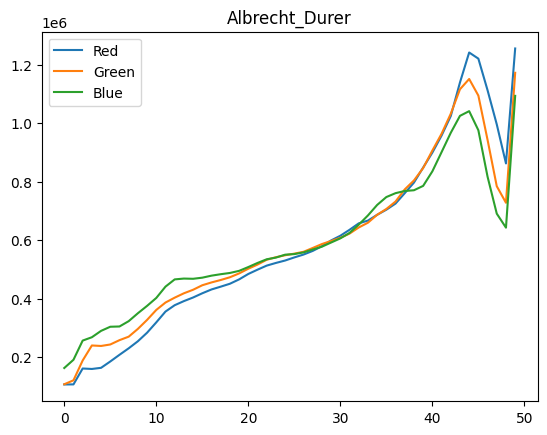

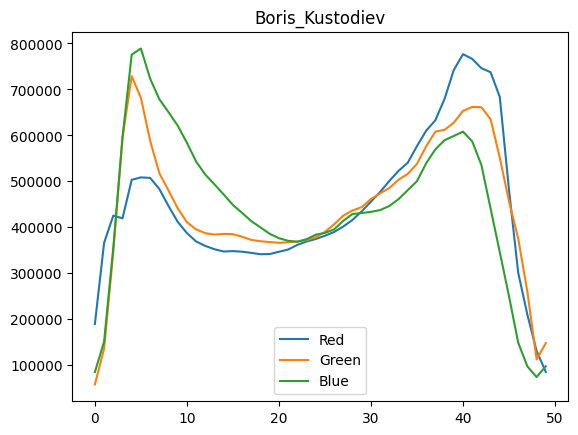

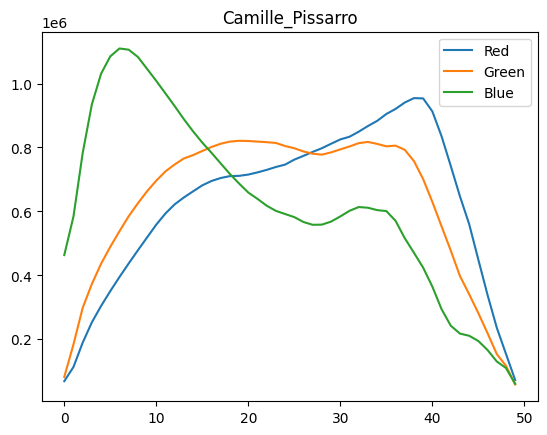

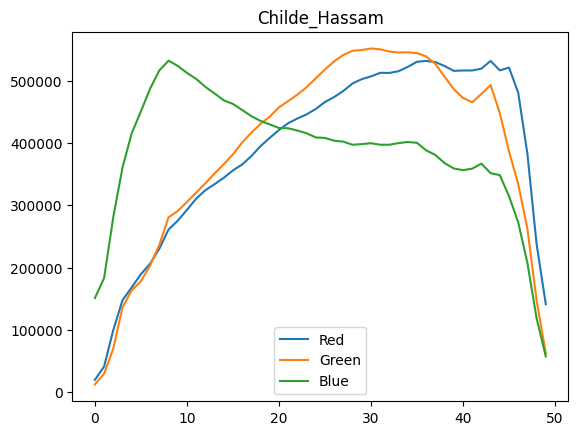

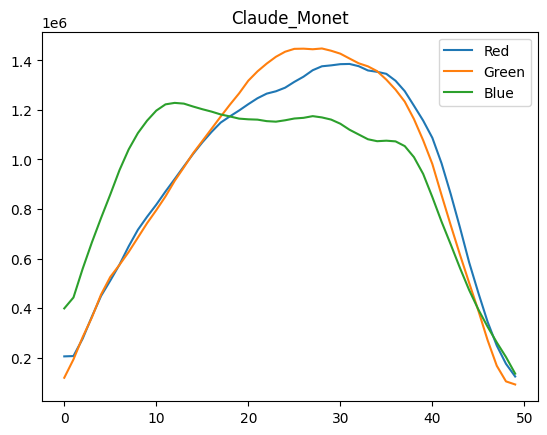

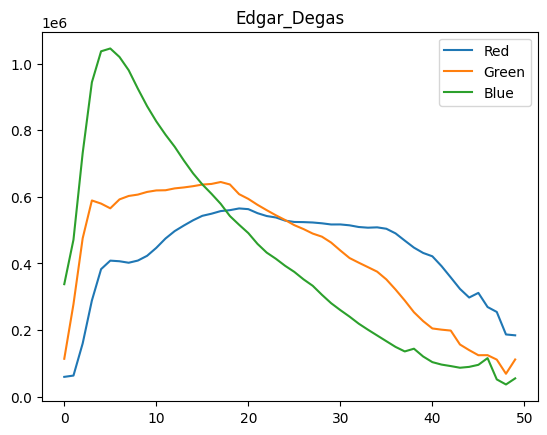

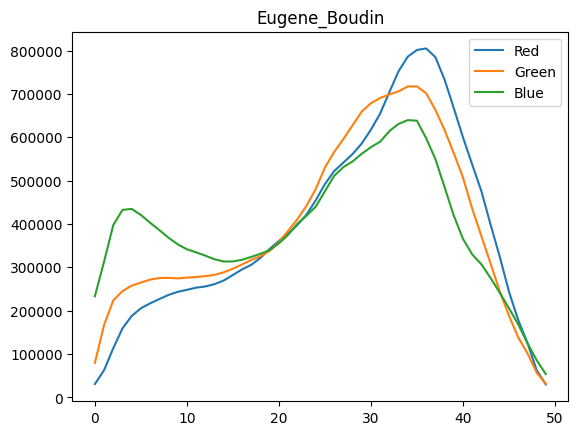

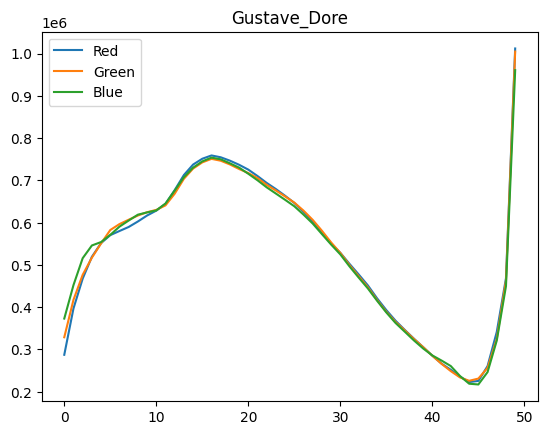

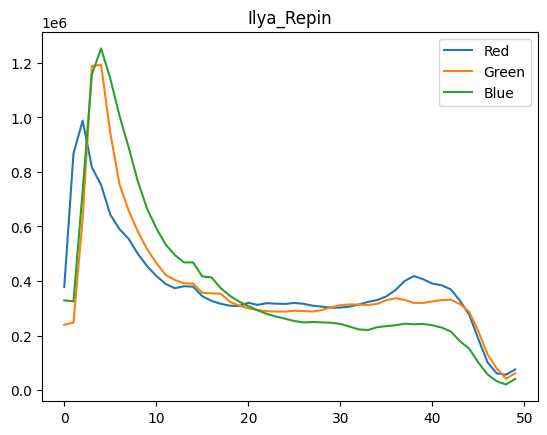

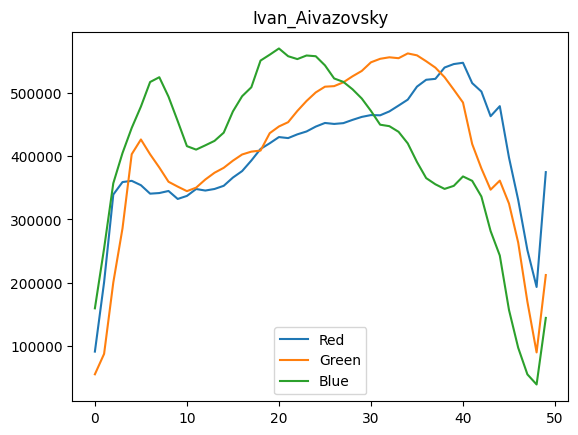

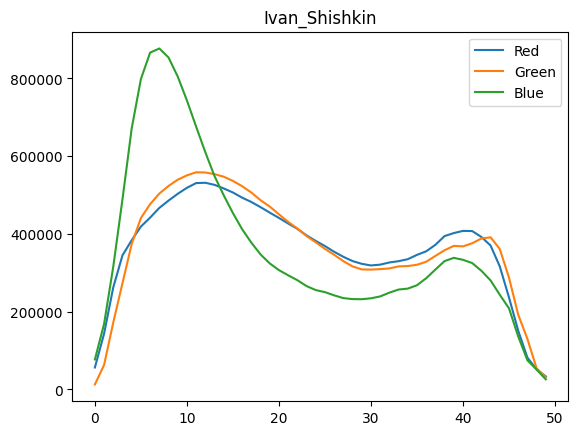

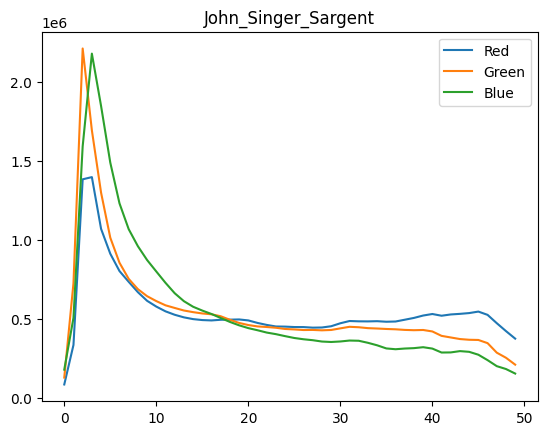

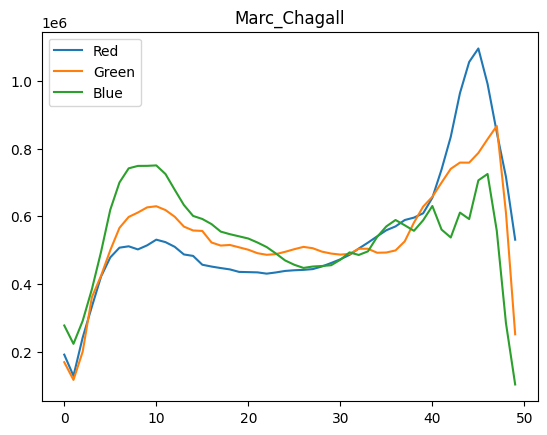

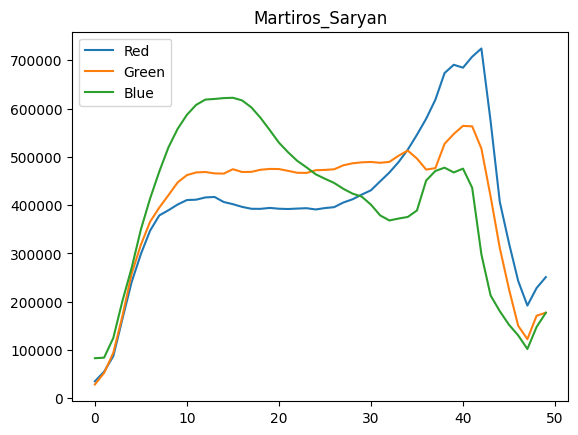

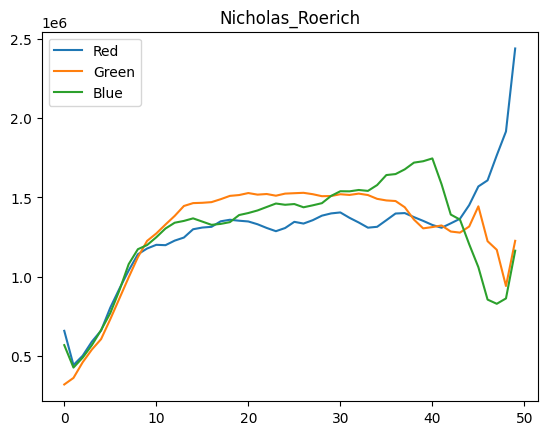

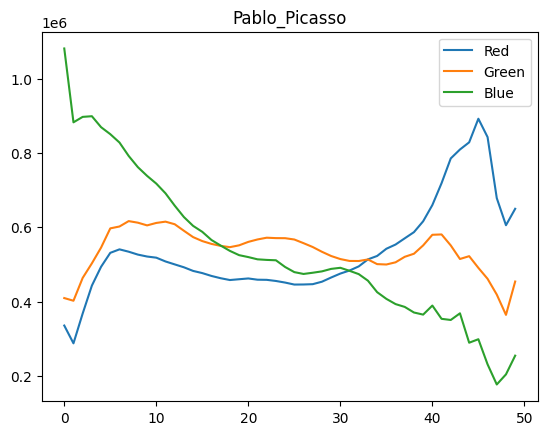

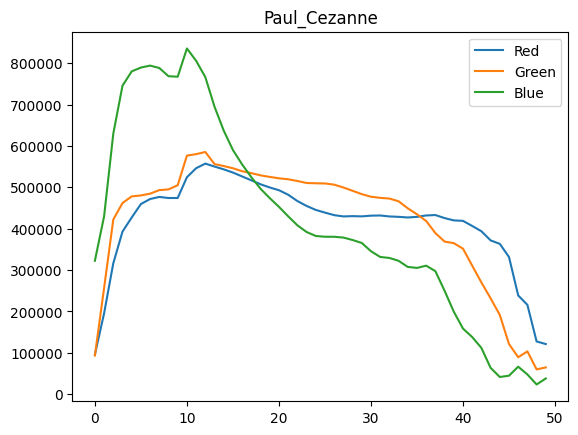

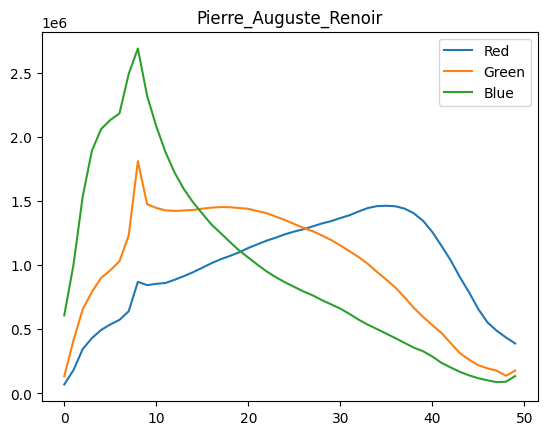

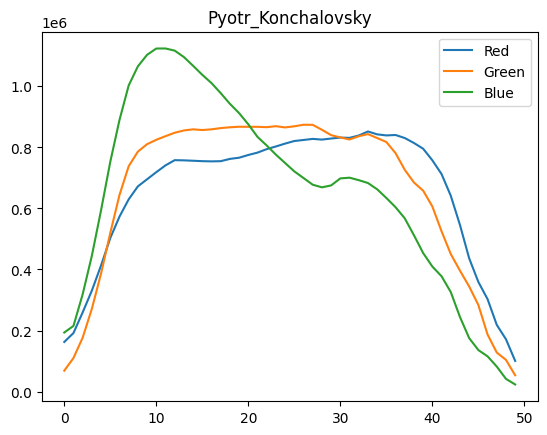

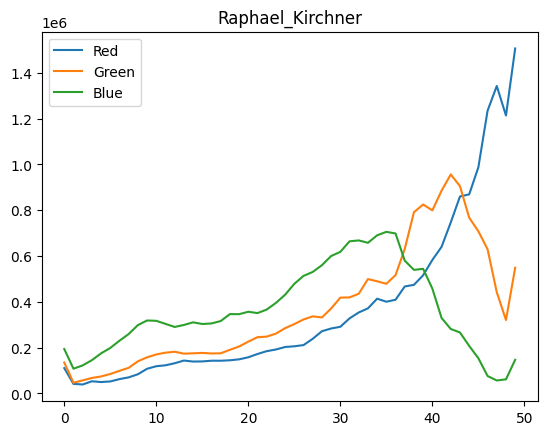

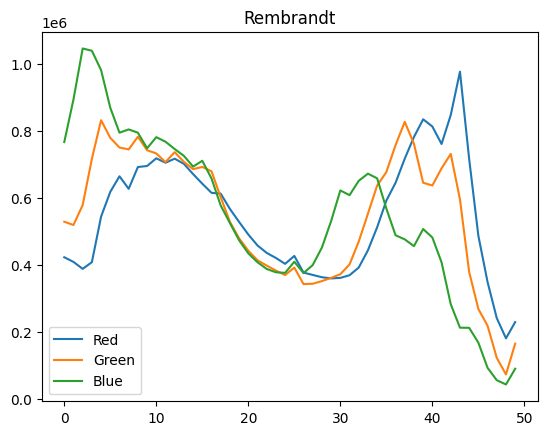

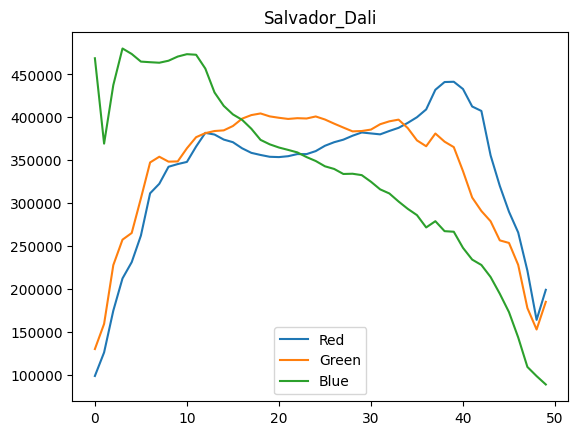

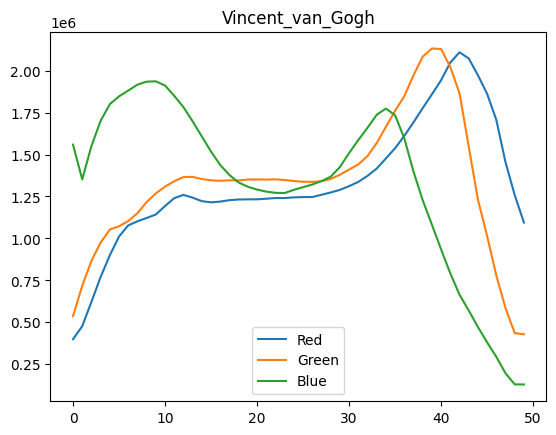

In [8]:
for i, class_name in enumerate(class_names):
    plt.figure()
    plt.plot(histograms[i]["R"], label="Red")
    plt.plot(histograms[i]["G"], label="Green")
    plt.plot(histograms[i]["B"], label="Blue")
    plt.title(class_name)
    plt.legend()
    plt.show()